In [1]:
from math import *
from sympy import *
init_printing(use_unicode=True)

Create symbols for sympy, 1 is inbound fluid layer, 2 is outbound solid.

In [2]:

a1 = symbols('alpha_1') # p,s velocity
a2 = symbols('alpha_2')
b2 = symbols('beta_2')
r1 = symbols('rho_1') # density
r2 = symbols('rho_2')
p = symbols('p') # ray param (flat earth)
na1 = symbols(r'\eta_{\alpha_1}') # eta, vertical slowness (flat earth)
na2 = symbols(r'\eta_{\alpha_2}')
nb2 = symbols(r'\eta_{\beta_2}')
e1 = symbols(r'e')
e2 = symbols(r'e^{t}')
f2 = symbols(r'f^{t}')


Create substitutions from the trig style to slowness style

In [3]:
cos2f2subs = [(cos(2*f2), 1-2*b2**2*p**2)]
trigsubs = [ (cos(e1), a1*na1), (cos(e2), a2*na2), (sin(f2), b2*p), 
            (sin(2*e2), 2*na2*a2*a2*p), (sin(2*f2), 2*nb2*b2*b2*p)
           ]

M matrix from Seismic Waves and Sources (Ben-Menahem, Ari, and Sarva Jit Singh. Springer-Verlag, 1981).


In [4]:
MM = Matrix( [ [ cos(e1), cos(e2), -sin(f2)],
              [ 0, sin(2*e2), a2/b2*cos(2*f2)],
              [ -1, r2*a2/(r1*a1)*cos(2*f2), -r2*b2/(r1*a1)*sin(2*f2)] ])
MM

⎡cos(e)      cos(e__{t})          -sin(f__{t})     ⎤
⎢                                                  ⎥
⎢                               α₂⋅cos(2⋅f__{t})   ⎥
⎢  0        sin(2⋅e__{t})       ────────────────   ⎥
⎢                                      β₂          ⎥
⎢                                                  ⎥
⎢        α₂⋅ρ₂⋅cos(2⋅f__{t})  -β₂⋅ρ₂⋅sin(2⋅f__{t}) ⎥
⎢  -1    ───────────────────  ─────────────────────⎥
⎣               α₁⋅ρ₁                 α₁⋅ρ₁        ⎦

Now substitute slowness for trig functions. We delay the cos(2f) term as
sympy simplify makes things uglier if we let it use this term.

In [5]:
M = MM.subs(trigsubs)
MM, M

⎛                                                      ⎡\eta_{\alpha_1}⋅α₁     ↪
⎜⎡cos(e)      cos(e__{t})          -sin(f__{t})     ⎤  ⎢                       ↪
⎜⎢                                                  ⎥  ⎢                       ↪
⎜⎢                               α₂⋅cos(2⋅f__{t})   ⎥  ⎢        0           2⋅ ↪
⎜⎢  0        sin(2⋅e__{t})       ────────────────   ⎥  ⎢                       ↪
⎜⎢                                      β₂          ⎥, ⎢                       ↪
⎜⎢                                                  ⎥  ⎢                       ↪
⎜⎢        α₂⋅ρ₂⋅cos(2⋅f__{t})  -β₂⋅ρ₂⋅sin(2⋅f__{t}) ⎥  ⎢                       ↪
⎜⎢  -1    ───────────────────  ─────────────────────⎥  ⎢        -1             ↪
⎝⎣               α₁⋅ρ₁                 α₁⋅ρ₁        ⎦  ⎣                       ↪

↪ \eta_{\alpha_2}⋅α₂                -β₂⋅p           ⎤⎞
↪                                                   ⎥⎟
↪                   2         α₂⋅cos(2⋅f__{t})      ⎥⎟
↪ \eta_{\alpha_2}⋅α₂ ⋅p 

Show the determiniate, using the cos(2f) term.

In [6]:
simplify(M.det()).subs(cos2f2subs)

Here is the corresponding determinate (more or less I think) from FMGS:

In [7]:
d_fmgs = a1*r1*na2 + a1*r2*na1*(4*b2**4*p**2*na2*nb2 + (1-2*b2**2*p**2)**2)
d_fmgs

Looks different to me and sympy doesn't help explain what is different, 
at least not in any simple way I can see.

In [8]:
simplify(M.subs(cos2f2subs).det()-d_fmgs)

Calculate the coefficiets, we factor out the determinate as that makes
coding the individual terms easier. So each term will need to be divided 
by M.det(). N represents the inbound P wave from the fluid layer, so zero for the S wave.

In [9]:
N = Matrix( [  a1*na1,  0, 1])
coef = (( M**-1 ) * N)

In [10]:
simplify(coef  * M.det()).subs(cos2f2subs)

⎡    ⎛                     ⎛                                                   ↪
⎢  2 ⎜                     ⎜                                   4  2   ⎛      2 ↪
⎢α₂ ⋅⎝- \eta_{\alpha_1}⋅ρ₂⋅⎝4⋅\eta_{\alpha_2}⋅\eta_{\beta_2}⋅β₂ ⋅p  + ⎝- 2⋅β₂  ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                                    β₂⋅ρ₁                     ↪
⎢                                                                              ↪
⎢                                                          ⎛      2  2    ⎞    ↪
⎢                                 -2⋅\eta_{\alpha_1}⋅α₁⋅α₂⋅⎝- 2⋅β₂ ⋅p  + 1⎠    ↪
⎢                                 ──────────────────────────────────────────   ↪
⎢                                                     β₂                       ↪
⎢                                                                              ↪
⎢                                                                        2     ↪
⎣                           

In [11]:
R = ( M**-1 ).subs(cos2f2subs) * N

R is the vector of reflection and transmission coefficients, as shown below.

In [12]:
Rpp = R[0]
Tpp = R[1]
Tps = R[2]

To verify, we calculate the input and output energy, which should balance:

In [13]:
outenergy = r1*a1*a1*na1*Rpp*Rpp + r2*a2*a2*na2*Tpp*Tpp + r2*b2*b2*nb2*Tps*Tps
inenergy = r1*a1*a1*na1
energy = outenergy-inenergy

In [14]:
inenergy

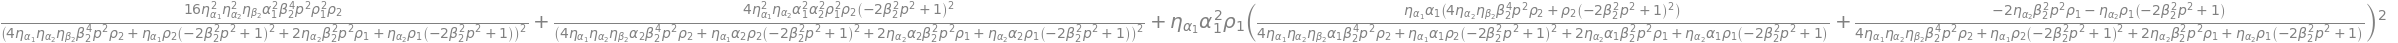

In [15]:
outenergy

In [16]:
simplify(outenergy-inenergy)

So the input energy is exactly matched by the outbound energy. This doesn't prove that the equations are correct, but energy balance is a necessary condition.

In [17]:

def eta(p,v):
    return sqrt(1/(v*v) - p*p)
# outer core to mantle, bot -> top
topVp = 13.6;
topVs = 7.2;
topDensity = 5.5;
botVp = 8;
botVs = 0;
botDensity = 10;
# example for 30 degree incidence
flatRP = sin(radians(30))/botVp;
e_in = asin(botVp*flatRP)
e_out = asin(topVp*flatRP)
f_out = asin(topVs*flatRP)
example = [ (a1, botVp), (r1, botDensity), (a2, topVp), (b2, topVs), (r2, topDensity),
           (p, flatRP), 
           (na1, eta(flatRP, botVp)),
           (na2, eta(flatRP, topVp)),
           (nb2, eta(flatRP, topVs)),
           (e1, e_in), (e2, e_out), (f2, f_out)
            ]
# and for vertical (0 degree incidence)
vertRP = 0
example_vert = [ (a1, botVp), (r1, botDensity), (a2, topVp), (b2, topVs), (r2, topDensity),
           (p, vertRP), 
           (na1, eta(vertRP, botVp)),
           (na2, eta(vertRP, topVp)),
           (nb2, eta(vertRP, topVs)),
           (e1, 0), (e2, 0), (f2, 0)
            ]

A numerical example for an outer core K to mantle P and S, with these parameters, where
1 is outer core, 2 is mantle:

In [18]:
example

In [19]:
energy.subs(example), energy.subs(example_vert)

In [20]:
inenergy.subs(example)

In [21]:
outenergy.subs(example)

In [22]:
M.subs(example)

⎡0.866025403784439  0.526782687642637        -0.45       ⎤
⎢                                                        ⎥
⎢        0          0.895530568992483   1.12388888888889 ⎥
⎢                                                        ⎥
⎣       -1              0.556325       -0.397844221241179⎦

In [23]:
MM.subs(example)

⎡0.866025403784439  0.526782687642637        -0.45       ⎤
⎢                                                        ⎥
⎢        0          0.895530568992483   1.12388888888889 ⎥
⎢                                                        ⎥
⎣       -1              0.556325       -0.397844221241179⎦

In [24]:
R.subs(example)

⎡-0.0785906918674138⎤
⎢                   ⎥
⎢ 1.05504934388693  ⎥
⎢                   ⎥
⎣-0.840678245498352 ⎦

In [25]:
print(R[0].subs(example))
print(R[1].subs(example))
print(R[2].subs(example))


-0.0785906918674138
1.05504934388693
-0.840678245498352


In [26]:
R.subs(example_vert)

⎡-0.0335917312661498⎤
⎢                   ⎥
⎢ 1.03359173126615  ⎥
⎢                   ⎥
⎣         0         ⎦

In [27]:
print(R.subs(example_vert))

Matrix([[-0.0335917312661498], [1.03359173126615], [0]])
